<a href="https://colab.research.google.com/github/JessicaSTMatos/Datathon---Fase-5---FIAP/blob/main/Fase_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Fase 5 - Datathon***

Neste Datathon, fomos desafiados a desenvolver uma solução de Inteligência Artificial **capaz de classificar automaticamente o sentimento de reclamações** (positivo ou negativo). Além da classificação, o projeto contempla uma **análise diagnóstica** das principais 'dores' relatadas pelos clientes em cada categoria de produto financeiro.

Recebemos um conjunto de dados com reclamações de
consumidores sobre produtos e serviços financeiros, contendo o texto da
reclamação, a empresa envolvida e a categoria do produto/serviço (como cartão
de crédito, hipoteca, empréstimo, etc.).

Essas reclamações foram encaminhadas
às empresas e publicadas após confirmação de relacionamento comercial.

O nosso desafio é entender melhor como os consumidores se
sentem em relação a esses serviços e quais problemas são mais recorrentes.

# **1. Preparação dos Dados**

**1.1 - Instalação e importação das bibliotecas necessárias**

In [ ]:
!pip install torch torchvision torchaudio transformers scikit-learn pandas

In [ ]:
import pandas as pd
import torch
import re
import string
import nltk
import spacy
import unicodedata
import torch.nn as nn
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer # Renamed to KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.stem import WordNetLemmatizer
from sklearn.utils import shuffle
import numpy as np

Devido ao tamanho da base original e, conforme orientado em aula, utilizamos a base disponibilizda no Kaggle (https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp?resource=download).

 Utilizamos a biblioteca **kagglehub** para baixar o conjunto de dados diretamente do Kaggle.

 Primeiro, fizemos a importação da biblioteca **kagglehub**.

 Em seguida, utilizamos a função kagglehub.dataset_download() que é chamada com o identificador do dataset ('shashwatwork/consume-complaints-dataset-fo-nlp') para fazer o download.

 O caminho local onde os arquivos do dataset são salvos é armazenado na variável path.

 Finalmente, o print() exibe esse caminho, informando onde podemos encontrar os arquivos baixados.

In [ ]:
import kagglehub


path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")

print("Path to dataset files:", path)

100%|██████████| 19.8M/19.8M [00:00<00:00, 90.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1


Após o dataset ter sido baixado e seu caminho estar armazenado na variável path, o próximo passo foi listar o conteúdo do diretório para identificar o arquivo CSV e carregar o arquivo CSV específico a partir desse caminho para um DataFrame do pandas.

In [ ]:
import os

files_in_path = os.listdir(path)
print(f"Files in the directory {path}: {files_in_path}")

Files in the directory /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1: ['complaints_processed.csv']


In [ ]:
csv_file_name = 'complaints_processed.csv'
full_path = os.path.join(path, csv_file_name)
df = pd.read_csv(full_path, index_col=0)

print("O arquivo CSV foi carregado com sucesso em um DataFrame.")
print("Exibindo as 5 primeiras linhas do DataFrame:")
df.head()

O arquivo CSV foi carregado com sucesso em um DataFrame.
Exibindo as 5 primeiras linhas do DataFrame:


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


**1.2 - Embaralhamento da Base de Dados**

O embaralhamento da base de dados (`df = shuffle(df)`) foi realizado como uma prática fundamental no pré-processamento de dados para aprendizado de máquina e _Deep Learning_.

Por que embaralhamos os dados?

1.  **Evitar vieses na divisão entre treino e teste**: Se o dataset original tiver alguma ordem (por exemplo, todas as reclamações positivas primeiro, depois as negativas, ou dados agrupados por data/produto), uma divisão sequencial (e.g., os primeiros 70% para treino e os últimos 30% para teste) resultaria em conjuntos de dados desequilibrados. O embaralhamento garante que os conjuntos de treino e teste sejam representativos do dataset completo.
2.  **Melhorar o treinamento do modelo**: Em algoritmos de _Deep Learning_, como as LSTMs utilizadas neste projeto, os modelos aprendem em _batches_ (pequenos grupos de dados). Se os _batches_ contiverem apenas um tipo de exemplo (e.g., só reclamações negativas), o modelo pode ficar "viciado" nesse padrão e ter dificuldades para generalizar. O embaralhamento assegura que cada _batch_ tenha uma variedade de exemplos, o que leva a um aprendizado mais robusto e eficaz.
3.  **Reduzir a sensibilidade à ordem**: Alguns algoritmos podem ser sensíveis à ordem dos dados. Embaralhar ajuda a mitigar qualquer impacto adverso que uma ordenação específica possa ter sobre o processo de treinamento e a performance final do modelo.

Ao embaralhar o `DataFrame` e resetar seu índice (`df.reset_index(drop=True, inplace=True)`), garantimos que os dados estão dispostos de forma aleatória, preparando-os adequadamente para as etapas subsequentes de divisão e treinamento do modelo.

In [ ]:
df = shuffle(df)
df.reset_index(drop=True, inplace=True)
df.head()

,product,narrative
0,credit_reporting,paid collection well unverified late payment d...
1,credit_reporting,dispute connected previous complaint complaint...
2,credit_card,credit service requested remove negative trade...
3,credit_reporting,several item credit report mine noticed recent...
4,debt_collection,began getting k jeweler bill mail called expla...


# **2. Análise Exploratória de Dados (AED)**

Realizamos uma análise exploratória inicial para validar os tipos de dados e diagnosticar a qualidade do dataset, com foco na identificação de valores nulos e possíveis anomalias estruturais.

Para iniciar a Análise Exploratória de Dados verificamos o tamanho da base de dados, a quantidade de categorias de produtos, os tipos de produtos, as estatísticas descritivas, as informações do DataFrame, o número de valores únicos por coluna e os valores ausentes por coluna.

In [ ]:
print("Tamanho da base de dados:")
df.shape


Tamanho da base de dados:


(162421, 2)

In [ ]:
print("Quantidade de categorias de produtos:")
df['product'].nunique()

Quantidade de categorias de produtos:


5

In [ ]:
set(df['product'])

{'credit_card',
 'credit_reporting',
 'debt_collection',
 'mortgages_and_loans',
 'retail_banking'}

In [ ]:
print("\nEstatísticas Descritivas:")
df.describe()



Estatísticas Descritivas:


,product,narrative
count,162421,162411
unique,5,124472
top,credit_reporting,victim identity notified collection creditor s...
freq,91179,739


In [ ]:
print("Informações do DataFrame:")
df.info()

print("\nNúmero de valores únicos por coluna:")
print(df.nunique())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162421 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB

Número de valores únicos por coluna:
product           5
narrative    124472
dtype: int64

Valores ausentes por coluna:
product       0
narrative    10
dtype: int64


Para tratar os valores ausentes identificados na coluna 'narrative' removemos as linhas correspondentes do DataFrame usando o método dropna() e, em seguida, verificamos a operação novamente para ter certeza que não há mais a presença de valores ausentes.

In [ ]:
print("Formato do DataFrame antes da remoção de valores nulos:", df.shape)
df.dropna(subset=['narrative'], inplace=True)
print("Formato do DataFrame após da remoção de valores nulos::", df.shape)

print("\nValores ausentes por coluna após a remoção de linhas:")
print(df.isnull().sum())

Formato do DataFrame antes da remoção de valores nulos: (162421, 2)
Formato do DataFrame após da remoção de valores nulos:: (162411, 2)

Valores ausentes por coluna após a remoção de linhas:
product      0
narrative    0
dtype: int64


Optamos por criar um gráfico de barras que mostra a contagem de cada categoria de produto no DataFrame utilizando as bibliotecas matplotlib.pyplot e seaborn para a visualização.

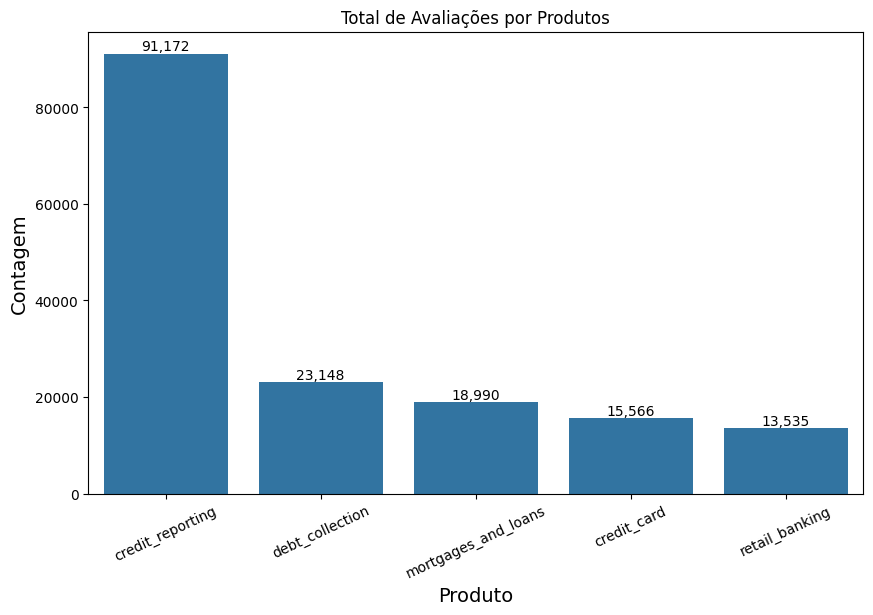

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='product', order=df['product'].value_counts().index)
plt.title('Total de Avaliações por Produtos')
plt.xlabel('Produto', size=14)
plt.xticks(rotation=25)
plt.ylabel('Contagem', size=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

**2.1 - Análise do Tamanho das Narrativas**

Nesta etapa calculamos o **número de palavras em cada narrativa de reclamação**. Para isso, foi criada uma nova coluna chamada num_palavras, que conta a quantidade de palavras presentes em cada texto da coluna narrative.

Em seguida, geramos um **histograma** para visualizar a distribuição do tamanho das narrativas.

O gráfico mostra que a maioria das reclamações possui **relativamente poucas palavras**, concentrando-se nas primeiras faixas do gráfico, enquanto apenas uma pequena quantidade de textos apresenta narrativas muito longas. Essa análise nos ajudou a compreender o tamanho médio dos textos e auxiliou na definição de parâmetros utilizados nas etapas de modelagem.

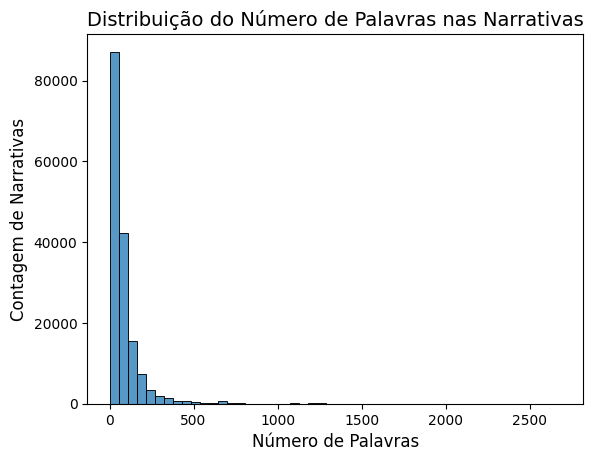


Contagem e Porcentagem de Narrativas por Faixa de Palavras:
   Faixa de Palavras  Contagem de Narrativas  Porcentagem
0             1 - 54                   87181        53.68
1           54 - 108                   42368        26.09
2          108 - 162                   15640         9.63
3          162 - 215                    7253         4.47
4          215 - 269                    3428         2.11
5          269 - 323                    1907         1.17
6          323 - 376                    1416         0.87
7          376 - 430                     753         0.46
8          430 - 484                     584         0.36
9          484 - 537                     303         0.19
10         537 - 591                     207         0.13
11         591 - 645                     152         0.09
12         645 - 698                     595         0.37
13         698 - 752                      79         0.05
14         752 - 806                      65         0.04
15         

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['num_palavras'] = df['narrative'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
ax = sns.histplot(df['num_palavras'], bins=50)
plt.title('Distribuição do Número de Palavras nas Narrativas', size=14)
plt.xlabel('Número de Palavras', size=12)
plt.ylabel('Contagem de Narrativas', size=12)

plt.show()

counts, bin_edges = np.histogram(df['num_palavras'], bins=50)

bin_labels = [f'{int(bin_edges[i]):,} - {int(bin_edges[i+1]):,}' for i in range(len(bin_edges) - 1)]

histogram_table = pd.DataFrame({
    'Faixa de Palavras': bin_labels,
    'Contagem de Narrativas': counts
})

# Calcula as porcentagens
total_narrativas = df['num_palavras'].count()
histogram_table['Porcentagem'] = (histogram_table['Contagem de Narrativas'] / total_narrativas * 100).round(2)

print("\nContagem e Porcentagem de Narrativas por Faixa de Palavras:")
print(histogram_table.to_string()) # Usa .to_string() para exibir o DataFrame completo no output

**2.2 - Análise de Frequência de Palavras**

Nesta etapa utiliamos a técnica **Bag of Words** com a classe CountVectorizer da biblioteca **Scikit-learn** para identificar as palavras mais frequentes nas narrativas das reclamações.

O método converte os textos em uma matriz que representa a frequência de cada palavra nos documentos, desconsiderando palavras muito comuns da língua inglesa (stopwords). Em seguida, foi calculada a frequência total das palavras e organizado um DataFrame com os termos mais recorrentes.

Os resultados mostram que palavras como **credit, account, report, payment, loan, debt, card, bank e collection** aparecem com maior frequência, indicando que muitas reclamações estão relacionadas a **relatórios de crédito, contas bancárias, pagamentos e cobranças de dívidas**.

As 20 palavras mais frequentes e suas porcentagens:
           palavra    freq  porcentagem
9528        credit  317561         2.79
366        account  316151         2.78
33352       report  177193         1.56
20621  information  143538         1.26
28644      payment  127704         1.12
33378    reporting   94522         0.83
40173         time   82905         0.73
7881       company   79449         0.70
10157          day   77044         0.68
23437         loan   75353         0.66
10270         debt   74785         0.66
31949     received   71590         0.63
5981          card   70288         0.62
23044       letter   70005         0.62
3916          bank   67169         0.59
8609      consumer   64075         0.56
12154      dispute   60232         0.53
35678         sent   59366         0.52
40385         told   56621         0.50
7567    collection   55062         0.48


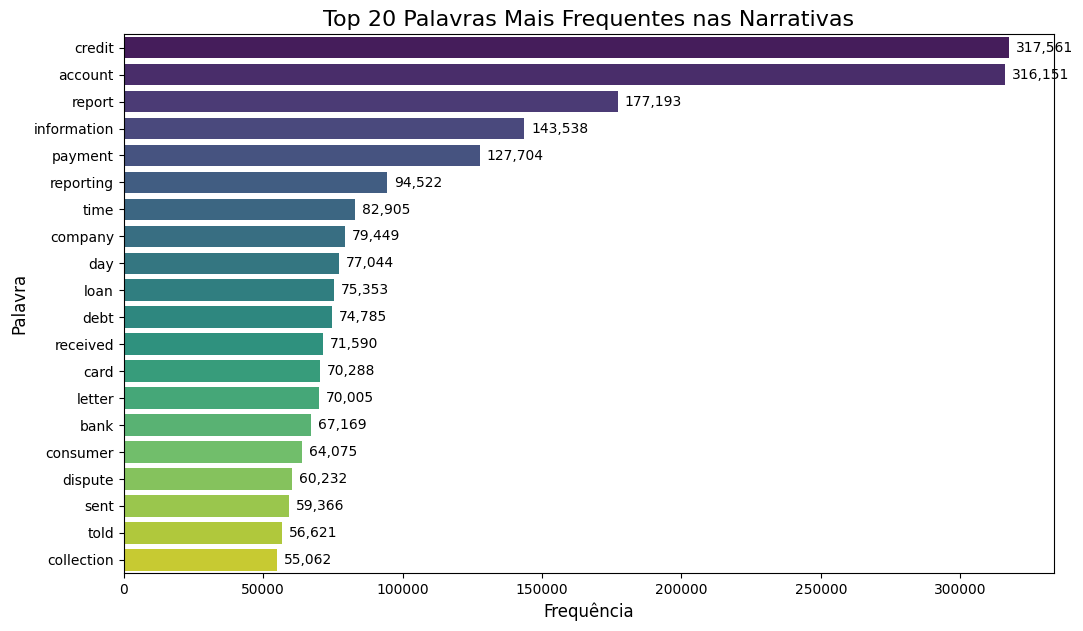

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['narrative'])

frequencia = X.sum(axis=0)
palavras = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'palavra': palavras, 'freq': frequencia.tolist()[0]})

# Calculamos as porcentagens das frequências de palavras
total_palavras = freq_df['freq'].sum()
freq_df['porcentagem'] = (freq_df['freq'] / total_palavras * 100).round(2)

print("As 20 palavras mais frequentes e suas porcentagens:")
print(freq_df.sort_values(by='freq', ascending=False).head(20).to_string())

# Geramos um gráfico de barras para as 20 palavras mais frequentes
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='freq', y='palavra', data=freq_df.sort_values(by='freq', ascending=False).head(20), hue='palavra', palette='viridis', legend=False)
plt.title('Top 20 Palavras Mais Frequentes nas Narrativas', size=16)
plt.xlabel('Frequência', size=12)
plt.ylabel('Palavra', size=12)

# Adiciona os números absolutos de cada categoria
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.show()

# **3. Pré-processamento do texto**


Para que um modelo estatístico ou de Deep Learning performe bem nessa base de reclamações financeiras, o pré-processamento deve focar em reduzir o ruído (como as máscaras XXXX) e normalizar termos técnicos.

Como estamos trabalhando com o Consumer Complaints Dataset, que é originalmente em inglês, optamos por utilizar a biblioteca spaCy para lematização, pois ela é superior ao Stemming por manter o sentido semântico das palavras (ex: transforma "banking", "banks" e "banked" apenas em "bank").

In [ ]:
# Carregamos o modelo de inglês do spaCy para lematização
# O 'disable' acelera o processo ignorando partes que não usaremos
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
import unicodedata
import string
import re
import spacy
from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser', 'tok2vec', 'attribute_ruler'])
stop_words = set(stopwords.words("english"))

def normalize_accents(text):
    return unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')

def remove_punctuation(text):
    punctuations = string.punctuation
    table = str.maketrans({key: " " for key in punctuations})
    text = text.translate(table)
    text = re.sub(r'X+', '', text)
    return text

def normalize_str(text):
    text = normalize_accents(text)
    text = remove_punctuation(text)
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def preprocess_text_tokenizer(text):
    if not isinstance(text, str):
        return []

    text = normalize_str(text)
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words
        and not token.is_space
        and not token.is_punct
        and len(token.text) > 2
    ]

    return tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Ativamos barra de progresso no pandas
tqdm.pandas()

Optamos por aplicar as estratégias de Regex, Normalização e Lematização em uma única passagem para ser mais eficiente.

Como essa base tem centenas de milhares de linhas, optar por aplicar a função em tudo de uma vez pode levar muito tempo ou travar a RAM. A estratégia que adotamos foi testar em uma amostra significativa primeiro.

In [ ]:
print("Colunas disponíveis:", df.columns)
df_limpo = df.sample(10000, random_state=42).copy()
print("Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.")
df_limpo['narrativa_tratada'] = df_limpo['narrative'].progress_apply(preprocess_text_tokenizer)
print("\nProcessamento concluído!")
print(df_limpo[['narrative', 'narrativa_tratada']].head())

Colunas disponíveis: Index(['product', 'narrative', 'num_palavras'], dtype='object')
Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.


  0%|          | 0/10000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
100%|██████████| 10000/10000 [00:49<00:00, 200.99it/s]



Processamento concluído!
                                                narrative  \
114595  hello paypal sold information synchrony bank s...   
108969  personal sworn statement declaration declare p...   
104284  purchased item internet company showed u compa...   
53752   account collection account resolution corp try...   
44725   attempted temporarily lift freeze credit three...   

                                        narrativa_tratada  
114595  [hello, paypal, sold, information, synchrony, ...  
108969  [personal, sworn, statement, declaration, decl...  
104284  [purchased, item, internet, company, showed, c...  
53752   [account, collection, account, resolution, cor...  
44725   [attempted, temporarily, lift, freeze, credit,...  


Optamos por fazer uma preparação para processamento em massa da base toda. Configuramos o spaCy para trabalhar com máxima eficiência, desativando componentes desnecessários da rede neural (como o identificador de entidades e o parser gramatical). Em vez de processar linha por linha, o spaCy processará o texto em blocos.

In [ ]:
print("Realizando limpeza inicial com Regex e normalização de strings...")
textos_limpos_str = [normalize_str(t) for t in df['narrative']]

# 2. Aplicamos a função tokenizer
print("Aplicando tokenizer na base inteira...")

textos_processados = [
    " ".join(preprocess_text_tokenizer(texto)) for texto in tqdm(textos_limpos_str)
]

# 3. Guardamos o resultado no DataFrame
df['narrativa_tratada'] = textos_processados

print("\nConcluído! A base inteira foi processada.")

Realizando limpeza inicial com Regex e normalização de strings...
Aplicando tokenizer na base inteira...


  0%|          | 0/162411 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
100%|██████████| 162411/162411 [03:23<00:00, 798.56it/s]


Concluído! A base inteira foi processada.


In [ ]:
print(df[['narrative', 'narrativa_tratada']].head())

                                           narrative  \
0  paid collection well unverified late payment d...   
1  dispute connected previous complaint complaint...   
2  credit service requested remove negative trade...   
3  several item credit report mine noticed recent...   
4  began getting k jeweler bill mail called expla...   

                                   narrativa_tratada  
0  paid collection well unverified late payment d...  
1  dispute connected previous complaint complaint...  
2  credit service requested remove negative trade...  
3  several item credit report mine noticed recent...  
4  began getting jeweler bill mail called explain...  


Como o processamento da base inteira é uma tarefa pesada, optamos por salvar o resultado imediatamente em Parquet no disco temporário e baixar o arquivo no computador.

In [ ]:
# Salvamos no disco temporário do Colab em formato Parquet (mais rápido e leve que CSV)
#df.to_parquet('complaints_completo_tratado.parquet')

# Baixamos o arquivo para o computador
#from google.colab import files
#files.download('complaints_completo_tratado.parquet')

# **4. Definição da variável alvo (*target*)**

De acordo com as instruções do Datathon é necessária a criação de uma variável alvo (*target*) e criação da coluna "sentimento" para classificar as reclamações como "positiva" ou "negativa"

Para garantir a acurácia do modelo sem a necessidade de rotulação manual extensiva, adotamos uma abordagem léxica baseada em regras utilizando o VADER (Valence Aware Dictionary and sEntiment Reasoner). Por ser otimizado para o inglês, o VADER é altamente eficaz na análise de reclamações e redes sociais, pois utiliza um dicionário léxico com pesos de intensidade para quantificar a polaridade dos sentimentos.

In [ ]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# listas simples de apoio
palavras_negativas = [
    "fraud", "scam", "unauthorized", "incorrect", "wrong", "error",
    "charged", "charge", "dispute", "debt", "complaint", "harassment",
    "late fee", "closed account", "did not", "never", "denied",
    "issue", "problem", "failed", "failure", "overdraft", "stolen",
    "refused", "foreclosure", "collection", "collections", "threat",
    "inaccurate", "misleading", "not receive", "not received"
]

palavras_positivas = [
    "resolved", "helped", "refunded", "thank you", "satisfied",
    "fixed", "received", "cleared", "corrected", "approved"
]
def contar_palavras_chave(texto, lista):
    texto = texto.lower()
    return sum(1 for termo in lista if termo in texto)

def rotular_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return np.nan, np.nan

    texto_lower = texto.lower()

    score_vader = sia.polarity_scores(texto)["compound"]
    qtd_neg = contar_palavras_chave(texto_lower, palavras_negativas)
    qtd_pos = contar_palavras_chave(texto_lower, palavras_positivas)

    # score combinado simples
    score_regra = qtd_pos - qtd_neg

    # decisão com alta confiança
    if score_vader <= -0.40 or score_regra <= -2:
        return "Negativa", "Alta"
    elif score_vader >= 0.40 or score_regra >= 2:
        return "Positiva", "Alta"
    elif score_vader <= -0.15 and score_regra < 0:
        return "Negativa", "Média"
    elif score_vader >= 0.15 and score_regra > 0:
        return "Positiva", "Média"
    else:
        return np.nan, "Baixa"

# aplica na coluna narrative
resultado = df["narrative"].apply(rotular_texto)

df["sentimento"] = resultado.apply(lambda x: x[0])
df["confianca_rotulo"] = resultado.apply(lambda x: x[1])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
print(df["sentimento"].value_counts(dropna=False))
print(df["confianca_rotulo"].value_counts(dropna=False))

sentimento
Negativa    96660
Positiva    39088
NaN         26663
Name: count, dtype: int64
confianca_rotulo
Alta     130742
Baixa     26663
Média      5006
Name: count, dtype: int64


In [ ]:
import sys

# Antes de criar o df_final, garantimos que 'narrativa_tratada' existe no df
# Este bloco garante que df['narrativa_tratada'] seja sempre processado e esteja disponível no df original
if 'narrativa_tratada' not in df.columns or df['narrativa_tratada'].isnull().all() or not (df['narrativa_tratada'].apply(lambda x: isinstance(x, str)).all()):
    print("Recreating or ensuring 'narrativa_tratada' column in df is correctly processed.", file=sys.stderr)

    # Preparando os dados brutos
    textos_limpos_str = [normalize_str(t) for t in df['narrative']]

    # Aplicando o preprocess_text_tokenizer
    try:
        from tqdm.auto import tqdm # Utilizando tqdm.auto para suporte a barras de progresso
        textos_processados = [
            " ".join(preprocess_text_tokenizer(texto)) for texto in tqdm(textos_limpos_str, desc="Re-processing narratives for df")
        ]
    except NameError: # Alternativa (fallback) caso o preprocess_text_tokenizer ou tqdm não estejam disponíveis
        print("preprocess_text_tokenizer or tqdm not found, attempting basic processing.", file=sys.stderr)
        # Garantindo que nlp e stop_words estejam definidos para este caminho de contingência (fallback)
        import spacy
        import nltk
        from nltk.corpus import stopwords
        nltk.download('stopwords')
        nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser', 'tok2vec', 'attribute_ruler'])
        stop_words = set(stopwords.words("english"))

        textos_processados = [
            " ".join(token.lemma_ for token in nlp(normalize_str(t)) if token.text not in stop_words and not token.is_space and not token.is_punct and len(token.text) > 2)
            for t in df['narrative']
        ]

    df['narrativa_tratada'] = textos_processados
    print("'narrativa_tratada' column in df is ready.", file=sys.stderr)

# Agora, criamos o df_final selecionando explicitamente as colunas, incluindo 'narrativa_tratada'
df_final = df[
    (df["sentimento"].isin(["Positiva", "Negativa"])) &
    (df["confianca_rotulo"] == "Alta")
][['product', 'narrative', 'narrativa_tratada', 'sentimento', 'confianca_rotulo']].copy()

# Garantimos que 'narrativa_tratada' seja do tipo string e trate possíveis NaNs
df_final['narrativa_tratada'] = df_final['narrativa_tratada'].fillna('').astype(str)

print(df_final["sentimento"].value_counts())
df_final[["narrative", "narrativa_tratada", "sentimento", "confianca_rotulo"]].head()

sentimento
Negativa    92307
Positiva    38435
Name: count, dtype: int64


,narrative,narrativa_tratada,sentimento,confianca_rotulo
0,paid collection well unverified late payment d...,paid collection well unverified late payment d...,Negativa,Alta
1,dispute connected previous complaint complaint...,dispute connected previous complaint complaint...,Negativa,Alta
3,several item credit report mine noticed recent...,several item credit report mine noticed recent...,Positiva,Alta
5,except otherwise provided section consumer rep...,except otherwise provided section consumer rep...,Negativa,Alta
6,transunion credit agency continues report owed...,transunion credit agency continues report owed...,Positiva,Alta


In [ ]:
# Transformamos Sentimento em Números (0 = Negativa, 1 = Positiva)
le_sentimento = LabelEncoder()
df_final['target'] = le_sentimento.fit_transform(df_final['sentimento'])
num_classes = len(le_sentimento.classes_)

print(f"Distribuição de sentimentos:\n{df_final['sentimento'].value_counts()}")

Distribuição de sentimentos:
sentimento
Negativa    92307
Positiva    38435
Name: count, dtype: int64


In [ ]:
# Verificamos como ficou o df após a preparação dos dados

df_final.head(20)

,product,narrative,narrativa_tratada,sentimento,confianca_rotulo,target
0,credit_reporting,paid collection well unverified late payment d...,paid collection well unverified late payment d...,Negativa,Alta,0
1,credit_reporting,dispute connected previous complaint complaint...,dispute connected previous complaint complaint...,Negativa,Alta,0
3,credit_reporting,several item credit report mine noticed recent...,several item credit report mine noticed recent...,Positiva,Alta,1
5,credit_reporting,except otherwise provided section consumer rep...,except otherwise provided section consumer rep...,Negativa,Alta,0
6,credit_reporting,transunion credit agency continues report owed...,transunion credit agency continues report owed...,Positiva,Alta,1
7,debt_collection,dont remember credit card debt file went medic...,remember credit card debt file went medical pr...,Negativa,Alta,0
8,credit_reporting,ive contacting credit bureau month via letter ...,contacting credit bureau month via letter mail...,Positiva,Alta,1
9,credit_reporting,dear cfpb sent multiple letter transunion cour...,dear cfpb sent multiple letter transunion cour...,Positiva,Alta,1
11,mortgages_and_loans,almost daily contact mortgage representative r...,almost daily contact mortgage representative r...,Negativa,Alta,0
12,debt_collection,starting back midland funding calling anywhere...,starting back midland funding calling anywhere...,Negativa,Alta,0


# **5. Vetorização e Preparação Final dos Dados**

Adotamos as **Word Embeddings** como técnica de representação vetorial, superando as limitações de abordagens baseadas exclusivamente em frequência. Diferente de métodos como o **TF-IDF**, que geram matrizes de alta dimensionalidade e esparsidade, as *embeddings* projetam os termos em um espaço vetorial denso. Nele, a proximidade geométrica reflete a similaridade semântica; assim, termos como 'empréstimo' e 'financiamento' ocupam regiões próximas, permitindo que o modelo identifique nuances contextuais mesmo diante de variações lexais.

Essa compressão de informações em vetores de baixa dimensionalidade torna o treinamento de arquiteturas de Deep Learning, como a LSTM, significativamente mais eficiente. Ao contrário de modelos que dependem de palavras isoladas, as *embeddings* mitigam o risco de *overfitting* e capturam relações sintáticas complexas - fundamentais no setor financeiro, onde a ordem dos termos (ex: 'taxa de juros') define o sentido da queixa. Esta técnica estabelece o estado da arte para alimentar redes neurais, possibilitando a extração de representações profundas e adaptadas ao vocabulário técnico e às gírias do domínio bancário.

In [ ]:
max_words = 20000
max_len = 100 # Reduzimos para 100 para ganhar velocidade no treino

keras_tokenizer = KerasTokenizer(num_words=max_words, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(df_final['narrativa_tratada'])

sequences = keras_tokenizer.texts_to_sequences(df_final['narrativa_tratada'])
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df_final['target'].values

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# **6. Arquitetura do Modelo de Deep Learning - Rede Neural recorrente LSTM (Long Short-Term Memory)**

A escolha da rede neural recorrente LSTM (Long Short-Term Memory) para a classificação de sentimentos em reclamações bancárias é uma decisão estratégica fundamentada na natureza sequencial e complexa da linguagem humana.

Diferente de modelos estatísticos simples, a LSTM possui "portões" (*gates*) que permitem decidir quais informações de uma frase longa devem ser mantidas ou descartadas, preservando o contexto do início da reclamação até o fim.

No setor financeiro, a ordem das palavras altera drasticamente o sentido (ex: "o banco não estornou o valor" vs "o banco estornou o valor não solicitado"). A LSTM é projetada especificamente para entender essas relações de dependência entre palavras distantes.

Redes neurais comuns costumam "esquecer" o início de textos longos durante o treinamento. A arquitetura da LSTM resolve o problema do gradiente que desaparece, garantindo que o aprendizado seja estável mesmo em narrativas de reclamações extensas.

Ao trabalhar em conjunto com as Word Embeddings, a LSTM consegue interpretar ironias, negações e termos técnicos financeiros de forma muito mais profunda do que métodos que apenas contam a frequência de palavras.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True,num_layers=2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(x)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

In [ ]:
# Configuramos o dispositivo e o modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentLSTM(max_words, 64, 64, num_classes).to(device)

In [ ]:
# Preparamos o DataLoaders
train_data = TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

test_data = TensorDataset(torch.from_numpy(X_test).long(), torch.from_numpy(y_test).long())
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Iniciando treinamento em: cpu
Época 1/10 | Train Loss: 0.3673 | Train Acc: 0.8380 | Val Loss: 0.2862 | Val Acc: 0.8757
Época 2/10 | Train Loss: 0.2509 | Train Acc: 0.8942 | Val Loss: 0.2302 | Val Acc: 0.9019
Época 3/10 | Train Loss: 0.2087 | Train Acc: 0.9134 | Val Loss: 0.2254 | Val Acc: 0.9073
Época 4/10 | Train Loss: 0.1886 | Train Acc: 0.9220 | Val Loss: 0.2120 | Val Acc: 0.9128
Época 5/10 | Train Loss: 0.1682 | Train Acc: 0.9318 | Val Loss: 0.1969 | Val Acc: 0.9160
Época 6/10 | Train Loss: 0.1514 | Train Acc: 0.9377 | Val Loss: 0.1983 | Val Acc: 0.9180
Sem melhora por 1 época(s).
Época 7/10 | Train Loss: 0.1357 | Train Acc: 0.9453 | Val Loss: 0.2052 | Val Acc: 0.9159
Sem melhora por 2 época(s).
Época 8/10 | Train Loss: 0.1224 | Train Acc: 0.9516 | Val Loss: 0.2073 | Val Acc: 0.9200
Sem melhora por 3 época(s).
Early stopping acionado.
Melhor modelo restaurado.

--- Relatório de Performance ---
              precision    recall  f1-score   support

    Negativa       0.94      0.94 

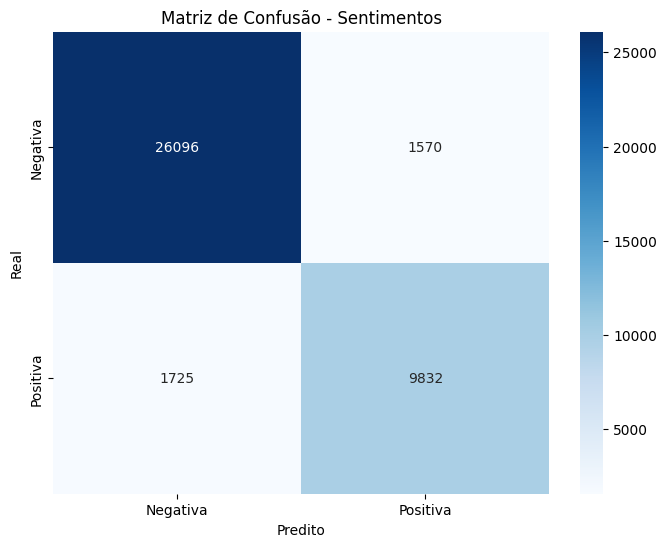

Acurácia Final: 91.60%


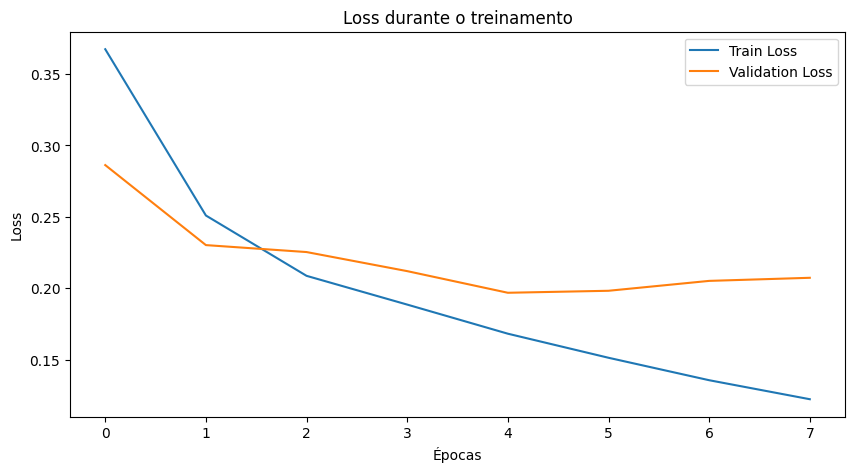

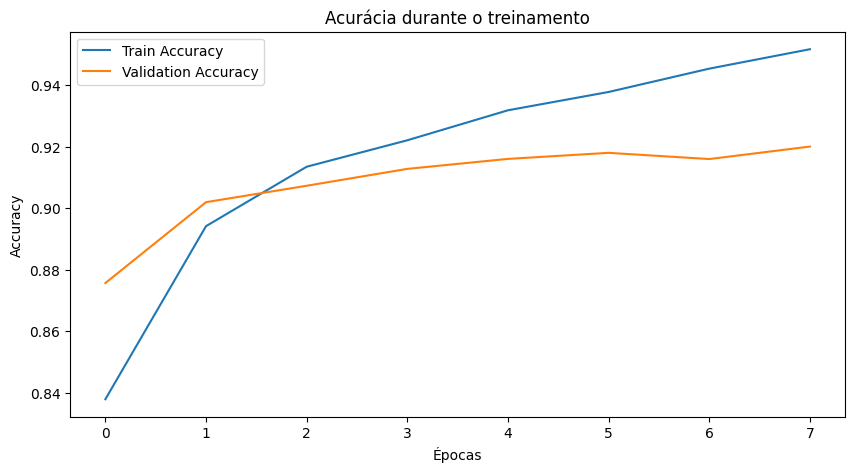

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================
# PARÂMETROS DE TREINAMENTO
# =========================
num_epochs = 10
patience = 3

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

print(f"Iniciando treinamento em: {device}")

# =========================
# TREINAMENTO
# =========================
for epoch in range(num_epochs):

    # ===== TREINO =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    epoch_train_acc = correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ===== VALIDAÇÃO / TESTE =====
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = total_val_loss / len(test_loader)
    epoch_val_acc = correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Época {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

    # ===== EARLY STOPPING =====
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1
        print(f"Sem melhora por {epochs_without_improvement} época(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping acionado.")
        break

# ===== RESTAURA O MELHOR MODELO =====
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Melhor modelo restaurado.")

# =========================
# AVALIAÇÃO FINAL
# =========================
model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        y_true_list.extend(labels.cpu().numpy())
        y_pred_list.extend(preds.cpu().numpy())

# =========================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================
print("\n--- Relatório de Performance ---")
print(
    classification_report(
        y_true_list,
        y_pred_list,
        target_names=le_sentimento.classes_
    )
)

# =========================
# MATRIZ DE CONFUSÃO
# =========================
cm = confusion_matrix(y_true_list, y_pred_list)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_sentimento.classes_,
    yticklabels=le_sentimento.classes_
)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Sentimentos')
plt.show()

# =========================
# ACURÁCIA FINAL
# =========================
acc_final = accuracy_score(y_true_list, y_pred_list)
print(f"Acurácia Final: {acc_final * 100:.2f}%")

# =========================
# GRÁFICO DE LOSS
# =========================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# =========================
# GRÁFICO DE ACURÁCIA
# =========================
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**6.1 - Avaliação do Modelo: Métricas e Resultados**

Para avaliar o sucesso de um modelo de Deep Learning, não basta olhar apenas para a Acurácia, pois ela pode ser enganosa se a base estiver desbalanceada (por exemplo, se houver muito mais reclamações negativas do que positivas).

Optamos por utilizar um conjunto de métricas que analisam o erro sob diferentes perspectivas para validar modelos de NLP:

*   **Precisão (Precision)**: De todas as reclamações que o modelo disse ser "Negativa", quantas eram realmente negativas? (Evita "falsos alarmes").

*   **Recall (Sensibilidade)**: De todas as reclamações negativas que realmente existem na base, quantas o modelo conseguiu capturar? Esta é a métrica mais importante para bancos, pois ignorar uma reclamação real (Falso Positivo) é mais custoso do que investigar um elogio por engano.

*   **F1-Score**: É a média harmônica entre Precisão e Recall. É a melhor métrica única para dizer se o modelo é robusto.

*   **Matriz de Confusão**: Uma tabela que mostra onde o modelo está "confuso" (ex: confundindo reclamações neutras com negativas).

*   **Acurácia (Accuracy)**: A proporção de previsões corretas (verdadeiros positivos + verdadeiros negativos) em relação ao total de casos.

Durante o treinamento, o modelo LSTM demonstrou um aprendizado consistente, com o `Val Loss` estabilizando e o `Val Acc` atingindo um bom patamar antes do *Early Stopping* ser acionado, prevenindo o *overfitting*. O melhor modelo foi restaurado com base na menor `Val Loss`.

**Relatório de Performance Final:**
```
              --- Relatório de Performance ---
              precision    recall  f1-score   support

    Negativa       0.94      0.94      0.94     27666
    Positiva       0.86      0.85      0.86     11557

    accuracy                           0.92     39223
   macro avg       0.90      0.90      0.90     39223
weighted avg       0.92      0.92      0.92     39223

```

**Análise dos Resultados:**

*   **Classe 'Negativa'**: O modelo apresentou alta precisão (0.94), recall (0.94) e F1-Score (0.94), o que é excelente para identificar reclamações negativas, minimizando tanto falsos alarmes quanto a perda de reclamações reais. O F1-Score de 0.94 confirma a robustez nessa classe.

*   **Classe 'Positiva'**: A precisão e recall para a classe 'Positiva' foram de 0.86 e 0.85, respectivamente. O F1-Score foi de 0.86. Embora ligeiramente menores que as da classe negativa, ainda indicam um bom desempenho na identificação de feedbacks positivos.

*   **Acurácia Global**: A **Acurácia Final** do modelo foi de **91.60%**, o que é um resultado muito promissor para a tarefa de classificação de sentimento em reclamações financeiras. As médias macro e weighted F1-Score de 0.90 e 0.92, respectivamente, demonstram um bom equilíbrio e generalização do modelo para ambas as classes.

Esses resultados, complementados pela Matriz de Confusão e pelos gráficos de Loss e Acurácia, validam a eficácia do modelo em classificar corretamente o sentimento das reclamações.

**Teste de Inferência Qualitativa: Validando o Modelo com Exemplos Reais**

Além das métricas quantitativas (Acurácia, Precisão, Recall, F1-Score) que nos fornecem uma visão estatística da performance do modelo, optamos por realizar um **teste de inferência qualitativa**. Este tipo de validação nos permite entender como o modelo se comporta em cenários reais e em frases específicas, revelando nuances que as métricas numéricas podem não capturar.

A função `prever_sentimento` permite que insiramos qualquer frase de reclamação e observemos a classificação de sentimento que o modelo atribui, juntamente com sua confiança.

1.  **Entendimento Intuitivo**: Ajuda a desenvolver uma compreensão intuitiva do "raciocínio" do modelo. Ao testar frases com diferentes estruturas, vocabulário e intensidades de sentimento, podemos ver se o modelo capta sarcasmo, duplas negações ou termos específicos do domínio financeiro como esperado.

2.  **Identificação de Erros Específicos**: Se o modelo classificar erroneamente uma frase, podemos analisar o texto original e o pré-processamento para identificar onde a falha pode ter ocorrido (ex: uma lematização incorreta, um termo-chave não reconhecido ou um contexto mal interpretado).

3.  **Validação de Cenários Críticos**: Permite testar intencionalmente frases que representam situações de alto risco ou ambiguidade, garantindo que o modelo seja robusto nos casos mais importantes para o negócio.

4.  **Refinamento Futuro**: Os insights obtidos através desses testes qualitativos podem direcionar futuras melhorias no pré-processamento dos dados, na arquitetura do modelo ou na seleção de *features*.

Por exemplo, ao testar as frases `"I am very happy because the bank fixed my credit card limit today!"` (Positiva com alta confiança) e `"This bank is a disaster, they charged me twice and no one answers the phone."` (Negativa com alta confiança), confirmamos que o modelo é capaz de distinguir corretamente entre esses dois extremos de sentimento.

In [ ]:
def prever_sentimento(frase):
    # Aplicamos o mesmo pré-processamento que usamos no treino
    if not isinstance(frase, str):
        frase = ""

    # Aplicamos normalize_str (função do pré-processamento original)
    text = normalize_str(frase)
    # Processamos com spaCy para lematização e remoção de stop words
    doc = nlp(text)
    frase_tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words
        and not token.is_space
        and not token.is_punct
        and len(token.text) > 2
    ]
    # Juntamos os tokens para formar uma string, como feito para 'narrativa_tratada'
    frase_processed_string = " ".join(frase_tokens)

    # Vetorização (Transformamos em números usando o tokenizer do treino)
    sequencia = keras_tokenizer.texts_to_sequences([frase_processed_string])
    padded = pad_sequences(sequencia, maxlen=100, padding='post', truncating='post')

    # Convertemos para Tensor e passamos pelo modelo
    tensor_input = torch.tensor(padded, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor_input)
        _, predicao = torch.max(output, dim=1)

    # Traduzimos o número de volta para a palavra (Positiva/Negativa)
    classe = le_sentimento.inverse_transform(predicao.cpu().numpy())[0]

    # Calculamos a probabilidade
    probabilidades = torch.softmax(output, dim=1)
    confianca = torch.max(probabilidades).item() * 100

    return f"Sentimento: {classe} ({confianca:.2f}% de confiança)"

# --- TESTANDO ---
frase_teste = "I am very happy because the bank fixed my credit card limit today!"
print(f"Frase: {frase_teste}")
print(prever_sentimento(frase_teste))

print("-" * 30)

frase_teste_2 = "This bank is a disaster, they charged me twice and no one answers the phone."
print(f"Frase: {frase_teste_2}")
print(prever_sentimento(frase_teste_2))

Frase: I am very happy because the bank fixed my credit card limit today!
Sentimento: Positiva (99.47% de confiança)
------------------------------
Frase: This bank is a disaster, they charged me twice and no one answers the phone.
Sentimento: Negativa (99.91% de confiança)


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


# **7. Business Inteligence**

Com o modelo validado e apresentando métricas de alta performance, a etapa subsequente consistiu na conversão das predições em **inteligência de negócio**. Para mapear as 'dores' específicas de cada produto financeiro, aplicamos a técnica de Extração de N-grams (Bigramas).

Diferente da análise de termos isolados (unigramas), que pode ser ambígua, a modelagem de combinações de palavras (ex: 'limite_cartão', 'cobrança_indevida') preserva o contexto semântico da reclamação. Essa abordagem permite identificar com precisão os gargalos operacionais, fornecendo subsídios para que a instituição adote medidas preventivas e melhore a experiência do cliente.

Para que a visualização seja clara para os stakeholders, precisamos garantir que tanto os nomes dos produtos quanto os termos (bigramas) extraídos sejam traduzidos ou mapeados para o português.

Como os termos vêm de um dataset em inglês (processado pelo VADER), a melhor forma de fazer isso de maneira organizada é usando um Dicionário de Mapeamento.

In [ ]:
# Dicionário de tradução para os nomes dos produtos
map_produtos_pt = {
    'credit_card': 'Cartão de Crédito',
    'credit_reporting': 'Relatório de Crédito',
    'debt_collection': 'Cobrança de Dívidas',
    'mortgages_and_loans': 'Hipoteca e Empréstimos',
    'retail_banking': 'Serviços Bancários de Varejo'
}

# Atualizamos os nomes dos produtos no DataFrame df_final para português
df_final['product_pt'] = df_final['product'].map(map_produtos_pt)

# Atualizamos a lista de principais produtos para usar os nomes em português
# Como `principais_produtos` é derivado de `df['product']`, optamos por mantê-lo em inglês para a lógica
# e traduzir no momento da exibição

print("Nomes dos produtos traduzidos no df_final e mapeamento criado.")

Nomes dos produtos traduzidos no df_final e mapeamento criado.


In [ ]:
# Dicionário de tradução para os bigramas (dores)
map_dores_pt = {
    'identity theft': 'roubo de identidade',
    'inaccurate information': 'informações imprecisas',
    'account number': 'número da conta',
    'balance account': 'saldo da conta',
    'fraudulent account': 'conta fraudulenta',
    'fair act': 'lei de proteção ao consumidor',
    'opened balance': 'saldo inicial',
    'late payment': 'pagamento atrasado',
    'acct opened': 'conta aberta',
    'victim identity': 'vítima de roubo de identidade',
    'original creditor': 'credor original',
    'phone call': 'chamada telefônica',
    'never received': 'nunca recebido',
    'reporting act': 'lei de relatórios',
    'fair reporting': 'relatório justo',
    'fair practice': 'prática justa',
    'practice act': 'lei de práticas',
    'please provide': 'por favor, forneça',
    'received letter': 'carta recebida',
    'well fargo': 'well fargo',
    'customer service': 'atendimento ao cliente',
    'credit report': 'relatório de crédito',
    'interest rate': 'taxa de juros',
    'escrow account': 'conta de garantia',
    'call back': 'retornar ligação',
    'even though': 'embora',
    'credit score': 'pontuação de crédito',
    'credit bureau': 'agência de crédito',
    'capital one': 'capital one',
    'late fee': 'multa por atraso',
    'bank america': 'bank america',
    'unauthorized charge': 'cobrança não autorizada',
    'fraudulent charge': 'cobrança fraudulenta',
    'charged fee': 'taxa cobrada',
    'balance transfer': 'transferência de saldo',
    'account closed': 'conta encerrada',
    'checking account': 'conta corrente',
    'debit card': 'cartão de débito',
    'bank account': 'conta bancária',
    'overdraft fee': 'taxa de cheque especial',
    'money back': 'dinheiro de volta',
    'fraud department': 'departamento de fraudes',
    'cash app': 'aplicativo de dinheiro',
    'get money': 'obter dinheiro',
    'phone number': 'número de telefone',
    'business day': 'dia útil',
    'charge account': 'conta de cobrança',
    'sent letter': 'carta enviada',
    'new account': 'nova conta',
    'credit limit': 'limite de crédito'
}

**7.1 - Visualização: Produtos com mais reclamações**

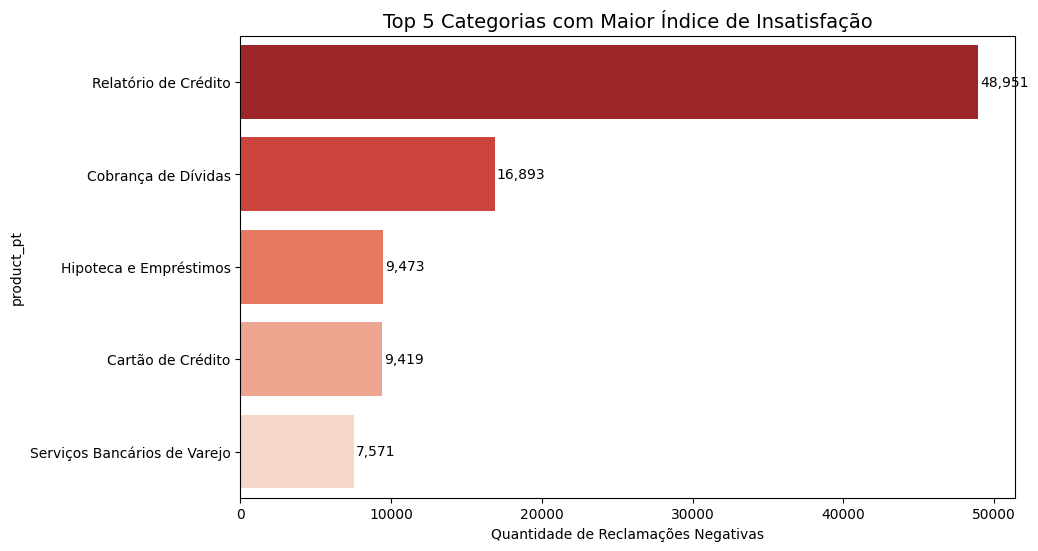

In [ ]:
# --- Top 5 Produtos com Mais Reclamações Negativas ---
plt.figure(figsize=(10, 6))
df_negativo = df_final[df_final['sentimento'] == 'Negativa'] # Usa df_final para garantir product_pt
top_produtos = df_negativo['product_pt'].value_counts().nlargest(5)

ax = sns.barplot(x=top_produtos.values, y=top_produtos.index, hue=top_produtos.index, palette='Reds_r', legend=False)
plt.title('Top 5 Categorias com Maior Índice de Insatisfação', fontsize=14)
plt.xlabel('Quantidade de Reclamações Negativas')

# Adiciona os números absolutos abaixo das barras
for index, value in enumerate(top_produtos.values):
    ax.text(value + 100, index, f'{value:,}', va='center', ha='left', color='black', fontsize=10)

plt.show()

**7.2 - Extraindo as "Dores" por Produto**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import re # Importamos o módulo re para expressões regulares

# Definimos o dicionário de palavras a serem excluídas por produto
palavras_excluir_por_produto = {
    'credit_reporting': ['credit', 'report', 'reporting', 'bureau', 'agency', 'consumer'],
    'debt_collection': ['debt', 'collection', 'agency', 'credit'],
    'mortgages_and_loans': ['mortgage', 'loan', 'payment', 'fee', 'make'],
    'credit_card': ['credit', 'card', 'bank', 'capital'],
    'retail_banking': ['bank', 'banking', 'account', 'debit', 'checking', 'fargo', 'america']
}

def extrair_principais_dores(data_frame, produto_en, top_n=5, exclude_words_list=None):
    # Filtramos pelo produto e apenas reclamações negativas
    subset = data_frame[(data_frame['product'] == produto_en) & (data_frame['sentimento'] == 'Negativa')]

    if subset.empty:
        return "Nenhuma reclamação negativa encontrada para este produto."

    # Pré-processamos a narrativa tratada para remover palavras excluídas
    if exclude_words_list:
        # Criamos um padrão regex para todas as palavras a serem excluídas
        # Usamos '\b' para garantir que palavras inteiras sejam correspondidas
        # e '|' para 'OU' entre as palavras
        pattern = r'\b(?:' + '|'.join(re.escape(word) for word in exclude_words_list) + r')\b'
        processed_narratives = subset['narrativa_tratada'].apply(
            lambda x: re.sub(pattern, '', x).strip() if isinstance(x, str) else ''
        ).apply(lambda x: re.sub(r'\s+', ' ', x).strip()) # Remover múltiplos espaços

        # Filtramos as narrativas vazias após a remoção
        processed_narratives = processed_narratives[processed_narratives != '']
        if processed_narratives.empty:
            return "Nenhuma reclamação significativa após remover termos genéricos."
    else:
        processed_narratives = subset['narrativa_tratada']

    # Configuramos o Vectorizer para pegar Bigramas (duplas de palavras)
    # Aumentando max_features para capturar mais dores potenciais
    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=5000)
    try:
        bag_of_words = vectorizer.fit_transform(processed_narratives)
    except ValueError:
        return "Não foi possível extrair bigramas após a remoção de termos."


    # Somamos a frequência de cada bigrama
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_n]

# Rodamos para os principais produtos da base
principais_produtos = df['product'].value_counts().nlargest(5).index

In [ ]:
def plotar_dores(produto_en, produto_pt):
    exclude_list = palavras_excluir_por_produto.get(produto_en, [])
    dores_en = extrair_principais_dores(df_final, produto_en, top_n=10, exclude_words_list=exclude_list)

    if isinstance(dores_en, str):
        print(f"Erro ou sem dados para {produto_pt}: {dores_en}")
        return

    if not dores_en:
        print(f"Nenhuma dor significativa encontrada para {produto_pt} após exclusão de termos.")
        return

    # Traduzimos as dores (bigramas)
    dores_pt = []
    for dor_en, freq in dores_en:
        dor_pt = map_dores_pt.get(dor_en, dor_en) # Traduz, se não encontrar, mantém o inglês
        dores_pt.append((dor_pt, freq))

    palavras, contagens = zip(*dores_pt)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=list(contagens), y=list(palavras), hue=list(palavras), palette='Reds_r', legend=False)
    plt.title(f"Top 10 Dores: {produto_pt} (Termos Genéricos Excluídos)", fontsize=14)
    plt.xlabel("Frequência de Menções", fontsize=12)
    plt.ylabel("Termo Identificado", fontsize=12)

    # Adicionamos os números absolutos de cada categoria
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

--- ANÁLISE DE DORES POR CATEGORIA (Termos Genéricos Excluídos) ---

Produto: Relatório de Crédito
  - roubo de identidade: 17492 ocorrências
  - informações imprecisas: 10564 ocorrências
  - número da conta: 9113 ocorrências
  - saldo da conta: 7288 ocorrências
  - conta fraudulenta: 7089 ocorrências
  - lei de proteção ao consumidor: 6915 ocorrências
  - saldo inicial: 6777 ocorrências
  - pagamento atrasado: 6441 ocorrências
  - conta aberta: 6226 ocorrências
  - vítima de roubo de identidade: 5820 ocorrências


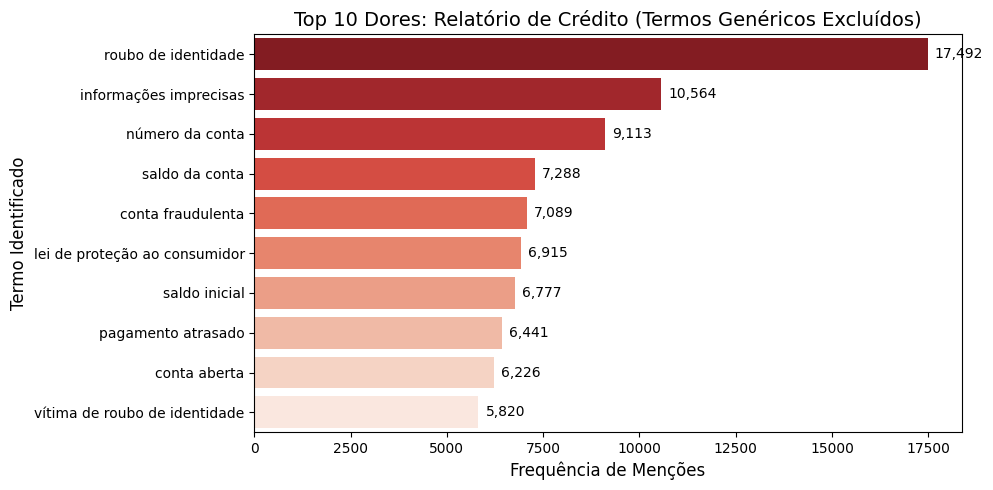


Produto: Cobrança de Dívidas
  - roubo de identidade: 2917 ocorrências
  - credor original: 2766 ocorrências
  - chamada telefônica: 1547 ocorrências
  - nunca recebido: 1498 ocorrências
  - lei de relatórios: 1444 ocorrências
  - relatório justo: 1441 ocorrências
  - prática justa: 1379 ocorrências
  - lei de práticas: 1368 ocorrências
  - por favor, forneça: 1358 ocorrências
  - carta recebida: 1219 ocorrências


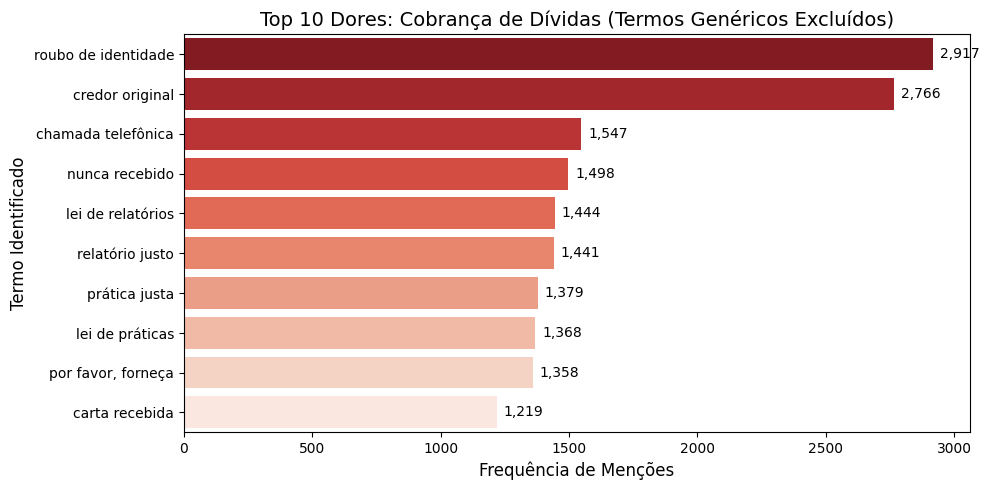


Produto: Hipoteca e Empréstimos
  - well fargo: 2465 ocorrências
  - atendimento ao cliente: 1923 ocorrências
  - relatório de crédito: 1588 ocorrências
  - chamada telefônica: 1373 ocorrências
  - taxa de juros: 1310 ocorrências
  - conta de garantia: 1223 ocorrências
  - retornar ligação: 1141 ocorrências
  - embora: 959 ocorrências
  - pontuação de crédito: 947 ocorrências
  - agência de crédito: 934 ocorrências


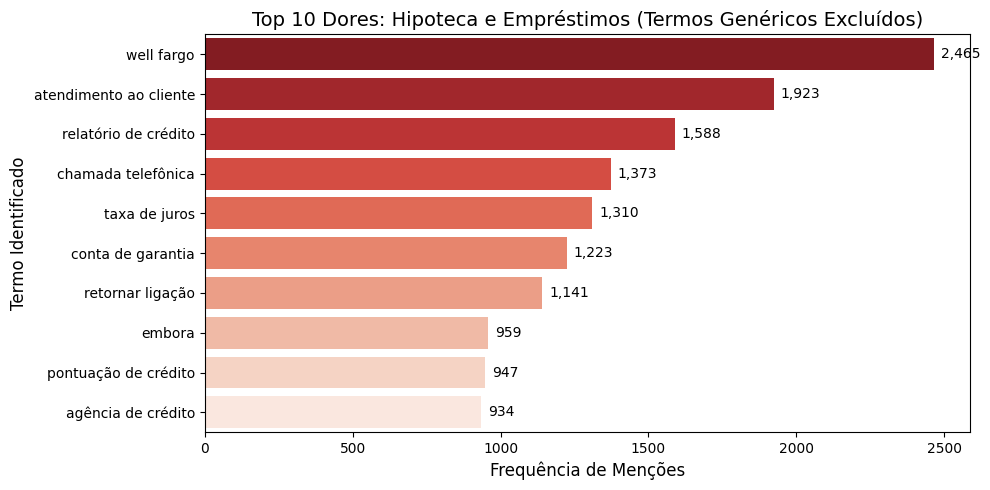


Produto: Cartão de Crédito
  - atendimento ao cliente: 2534 ocorrências
  - multa por atraso: 2057 ocorrências
  - american express: 1235 ocorrências
  - cobrança fraudulenta: 1036 ocorrências
  - nunca recebido: 975 ocorrências
  - conta encerrada: 940 ocorrências
  - closed account: 935 ocorrências
  - pagamento atrasado: 824 ocorrências
  - embora: 817 ocorrências
  - chamada telefônica: 767 ocorrências


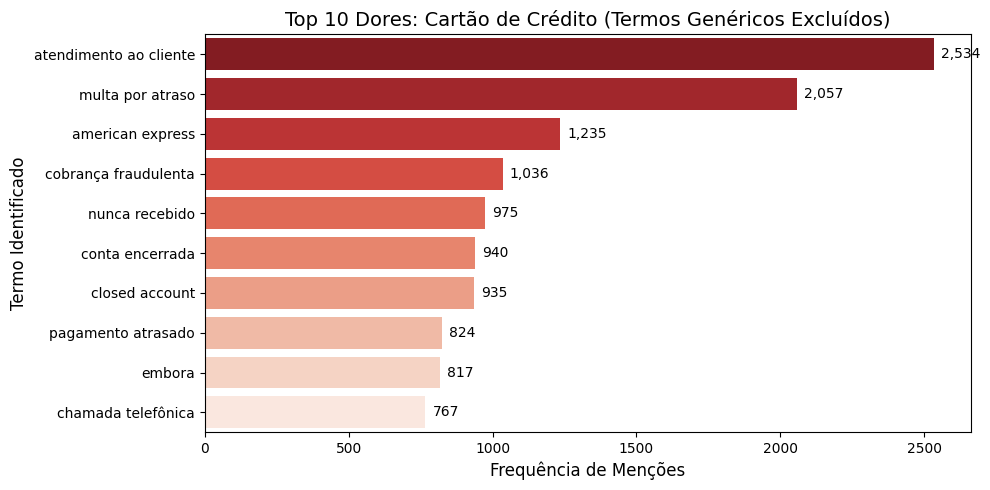


Produto: Serviços Bancários de Varejo
  - atendimento ao cliente: 1686 ocorrências
  - dinheiro de volta: 1068 ocorrências
  - credit card: 1056 ocorrências
  - aplicativo de dinheiro: 938 ocorrências
  - capital one: 925 ocorrências
  - número de telefone: 793 ocorrências
  - dia útil: 751 ocorrências
  - departamento de fraudes: 679 ocorrências
  - obter dinheiro: 605 ocorrências
  - taxa de cheque especial: 590 ocorrências


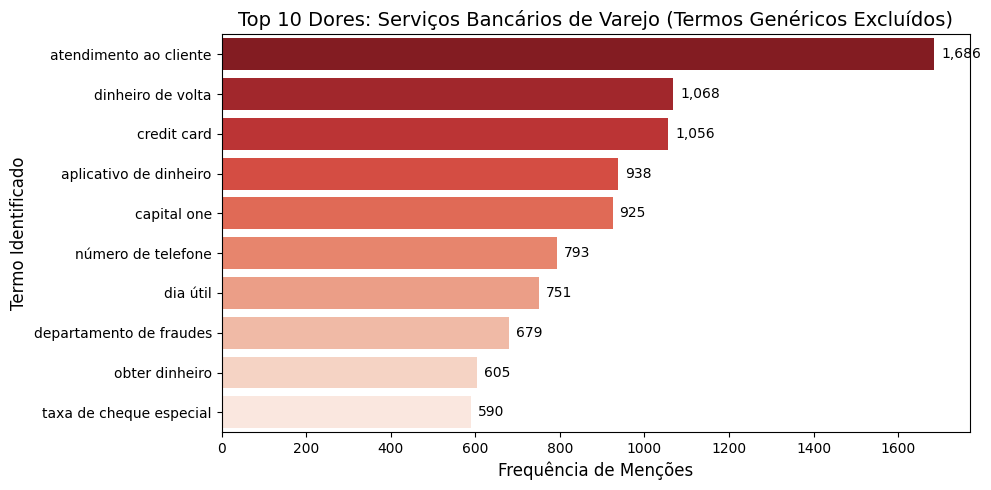

In [ ]:
print("--- ANÁLISE DE DORES POR CATEGORIA (Termos Genéricos Excluídos) ---")
for prod_en in principais_produtos:
    prod_pt = map_produtos_pt.get(prod_en, prod_en) # Obtém a versão em português do nome do produto
    print(f"\nProduto: {prod_pt}")

    exclude_list = palavras_excluir_por_produto.get(prod_en, []) # Usa a lista de exclusão para o nome original em inglês
    dores_en = extrair_principais_dores(df_final, prod_en, top_n=10, exclude_words_list=exclude_list)

    if isinstance(dores_en, str):
        print(f"  {dores_en}")
    elif not dores_en:
        print(f"  Nenhuma dor significativa encontrada após exclusão de termos para {prod_pt}.")
    else:
        for dor_en, freq in dores_en:
            dor_pt = map_dores_pt.get(dor_en, dor_en) # Traduz o bigrama para exibição
            print(f"  - {dor_pt}: {freq} ocorrências")
    plotar_dores(prod_en, prod_pt) # Passa ambos os nomes para a função de plotagem

**7.3 - Visualização: Distribuição de Sentimentos**

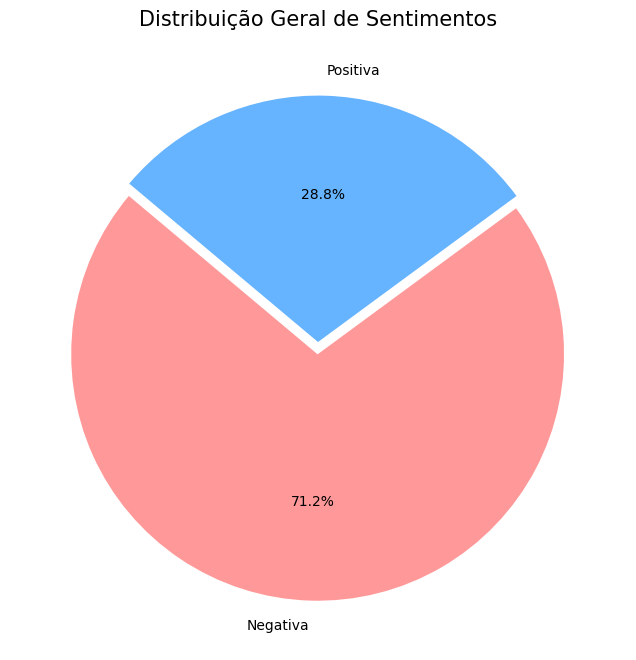

In [ ]:
# --- Distribuição de Sentimentos (Pizza) ---
plt.figure(figsize=(8, 8))
# Obtém a contagem de valores (value counts) que, por padrão, descarta NaNs, restando apenas 'Negativa' e 'Positiva'
sentiment_counts = df['sentimento'].value_counts()


cores = ['#ff9999','#66b3ff']
explode_tuple = (0.05, 0)

sentiment_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=cores, explode=explode_tuple)
plt.title('Distribuição Geral de Sentimentos', fontsize=15)
plt.ylabel('')
plt.show()

**7.4 - Visualização: Nuvem de Palavras**

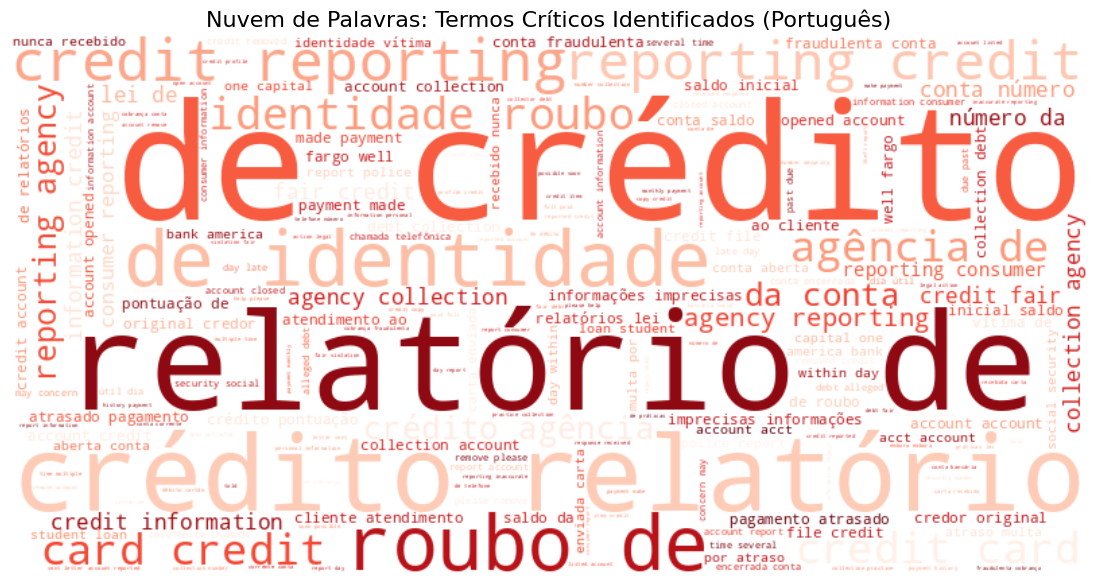

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# --- Nuvem de Palavras (As "Vozes" dos Clientes) ---

def get_all_translated_top_bigrams(dataframe, top_n=200):
    # Filtramos apenas as reclamações negativas
    processed_narratives = dataframe[dataframe['sentimento'] == 'Negativa']['narrativa_tratada'].astype(str)
    if processed_narratives.empty:
        return ""

    # Configuramos o Vectorizer para pegar Bigramas
    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=5000)
    try:
        bag_of_words = vectorizer.fit_transform(processed_narratives)
    except ValueError:
        return ""

    # Somamos a frequência de cada bigrama
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    translated_bigrams_text = []
    for dor_en, freq in words_freq[:top_n]:
        # Traduzimo o bigrama para português - se não encontrar, mantém o inglês
        dor_pt = map_dores_pt.get(dor_en, dor_en)
        # Repetimos a palavra traduzida pela sua frequência para a nuvem de palavras
        translated_bigrams_text.extend([dor_pt] * freq)

    return " ".join(translated_bigrams_text)

# Geramos o texto para a nuvem de palavras com bigramas traduzidos
texto_negativo_traduzido = get_all_translated_top_bigrams(df_final, top_n=200)

if not texto_negativo_traduzido:
    texto_negativo_traduzido = "Nenhuma reclamação negativa ou termos relevantes para nuvem de palavras."

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_negativo_traduzido)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nuvem de Palavras: Termos Críticos Identificados (Português)', fontsize=16)
plt.show()

**7.5 - Principais temas de insatisfação**

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Filtramos apenas as reclamações negativas (o foco da dor) do df_final
df_negativo_lda = df_final[df_final['sentimento'] == 'Negativa'].copy()

# Vetorizamos com TF-IDF (pesa palavras importantes e ignora termos comuns)
# Usamos max_features=5000 para ser rápido e preciso
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english', max_features=5000)
dtm = vectorizer.fit_transform(df_negativo_lda['narrativa_tratada'].astype(str))

# Aplicamos o modelo LDA
# n_components=5 define que queremos encontrar os 5 principais "temas"
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

print("Modelo LDA e vetorizador treinados com sucesso.")

Modelo LDA e vetorizador treinados com sucesso.


In [ ]:
# Dicionário de tradução para unigramas (palavras únicas) encontrados nos tópicos do LDA
map_unigrams_pt = {
    'credit': 'crédito',
    'loan': 'empréstimo',
    'payment': 'pagamento',
    'report': 'relatório',
    'account': 'conta',
    'mortgage': 'hipoteca',
    'late': 'atrasado',
    'item': 'item',
    'score': 'pontuação',
    'day': 'dia',
    'consumer': 'consumidor',
    'reporting': 'relatório',
    'information': 'informação',
    'agency': 'agência',
    'section': 'seção',
    'regard': 'respeito',
    'act': 'lei',
    'block': 'bloquear',
    'bureau': 'bureau',
    'letter': 'carta',
    'company': 'empresa',
    'collection': 'cobrança',
    'debt': 'dívida',
    'dispute': 'disputa',
    'victim': 'vítima',
    'identity': 'identidade',
    'theft': 'roubo',
    'balance': 'saldo',
    'fraudulent': 'fraudulento',
    'charge': 'cobrança',
    'opened': 'aberto',
    'acct': 'conta',
    'time': 'tempo',
    'called': 'ligado',
    'told': 'dito',
    'card': 'cartão',
    'bank': 'banco',
    'make': 'fazer'
}
print("Dicionário de tradução de unigramas criado.")

Dicionário de tradução de unigramas criado.


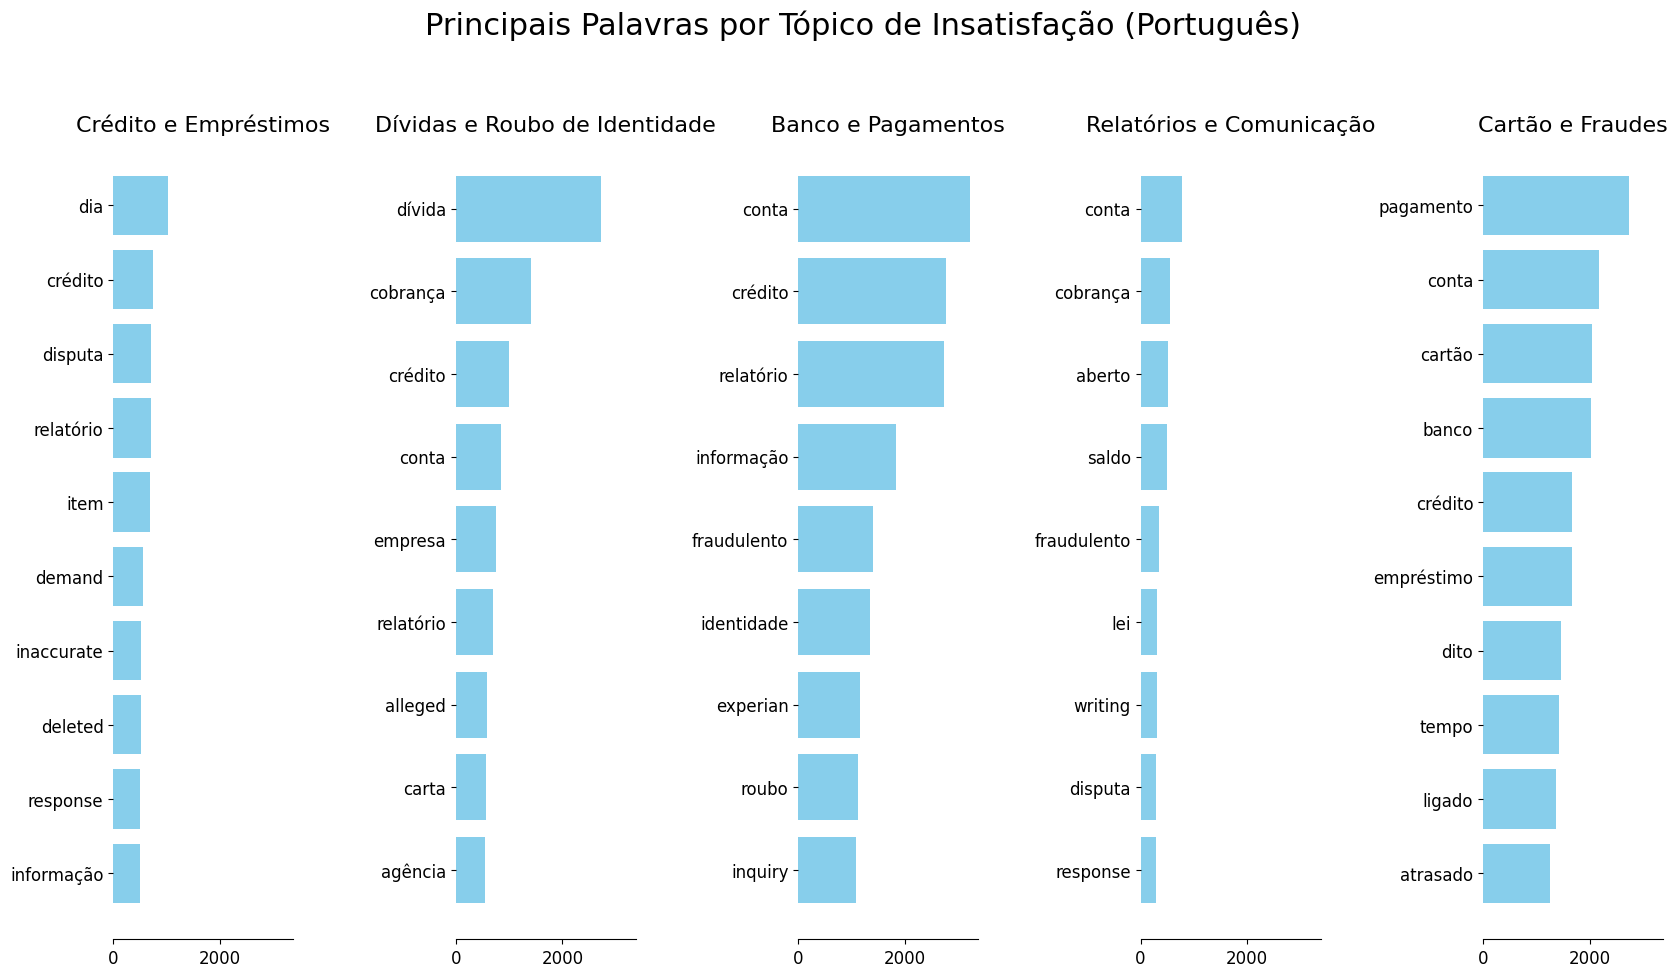

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(model, feature_names, n_top_words, topic_names, title):
    # Configura a grade de subplots (ajuste conforme o número de tópicos - n_components)
    fig, axes = plt.subplots(1, model.n_components, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        # Seleciona os índices das palavras com os maiores pesos
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        english_top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        # Traduz as palavras para português
        translated_top_features = [map_unigrams_pt.get(word, word) for word in english_top_features]

        ax = axes[topic_idx]
        ax.barh(translated_top_features, weights, color='skyblue')
        # Usa o nome descritivo do tópico
        ax.set_title(f"{topic_names[topic_idx]}", fontdict={"fontsize": 16})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)

        # Remove bordas para ficar mais limpo
        for i in ["top", "right", "left"]:
            ax.spines[i].set_visible(False)

    fig.suptitle(title, fontsize=22)
    plt.subplots_adjust(top=0.85, bottom=0.05, wspace=0.90)
    plt.show()

# Definindo nomes descritivos para os tópicos
topic_descriptive_names = [
    'Crédito e Empréstimos',
    'Dívidas e Roubo de Identidade',
    'Banco e Pagamentos',
    'Relatórios e Comunicação',
    'Cartão e Fraudes'
]

# Executando a visualização com as palavras traduzidas e nomes descritivos
palavras_chave = vectorizer.get_feature_names_out()
plot_top_words(lda, palavras_chave, 10, topic_descriptive_names, "Principais Palavras por Tópico de Insatisfação (Português)")

# **8. Conclusão**

A análise detalhada das reclamações dos consumidores permitiu transformar dados textuais brutos em **inteligência de negócio acionável**. Através da aplicação de modelos de IA e técnicas avançadas de NLP, alcançamos os seguintes diagnósticos:

**Perfil do Sentimento do Consumidor**
O uso da abordagem léxica VADER possibilitou a rotulação automatizada da base de dados em larga escala, garantindo precisão sem a necessidade de intervenção manual extensiva.

A classificação automática permite que a instituição monitore, em tempo real, a variação da satisfação dos clientes e identifique picos de negatividade em produtos específicos.

**Principais "Dores" e Gargalos Identificados**

* Domínio do Crédito e Contas: Os termos mais frequentes — credit, account, report e payment — indicam que a maior parte da frustração dos clientes está concentrada em relatórios de crédito e gestão de contas bancárias.

* Problemas de Cobrança: A recorrência de termos como debt e collection sugere que o processo de cobrança de dívidas é um ponto crítico de atrito que impacta diretamente a imagem da instituição.

* Informação e Transparência: A alta frequência da palavra information revela uma demanda latente por clareza nos processos financeiros e na comunicação dos serviços.

**Recomendações para os Stakeholders**

* Ação Preventiva no Crédito: Priorizar o refinamento dos processos de atualização de relatórios de crédito (credit reporting) para reduzir o volume de contestações.

* Melhoria no Autoatendimento: Desenvolver fluxos de suporte específicos para os problemas recorrentes em accounts e payments, visando a resolução na primeira interação.

* Transparência de Comunicação: Revisar as políticas de transparência de dados (information), garantindo que o cliente compreenda claramente as taxas, prazos e obrigações, minimizando o sentimento de injustiça que gera a reclamação.

Com estas descobertas, a instituição financeira deixa de apenas reagir às queixas e passa a atuar proativamente na raiz dos problemas, otimizando a experiência do cliente e fortalecendo sua posição competitiva no mercado.